# Notebook 17 — Phase-1 categorical-POMDP scaffold (smoke + structural finding)

Exercises the Phase-1 scaffold (`src/pomdp/gen_model`, `agent_pop`, `step`, `observables`): a
fixed-state epistemic POMDP where paradigm $\theta$ is the inferred hidden state ($B=$ identity),
experiments are measurements, the social channel is softmax-precision (NB15), and **belief-utility
$U(\theta)$ enters EFE/policy only — never the belief update**.

It also documents the **central structural finding of Phase 1**, surfaced rather than forced:

> With honest Bayesian inference against a truthful environment, belief-utility confined to policy
> **cannot produce paradigm capture-against-evidence** (the martingale wall). Capture comes from the
> **social fold + initial-condition basin selection**; belief-utility only modulates exploration.

This is the same wall that the NB14 λ·U blow-up was a symptom of, and it sharpens the question of
where capture should live (see the closing fork).

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT if (ROOT / "src").exists() else ROOT.parent))

import numpy as np
import matplotlib.pyplot as plt

from src.pomdp.gen_model import PomdpConfig, build_generative_model, discriminability
from src.pomdp.agent_pop import policy_posterior
from src.pomdp import step as S, observables as O

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

# theory-laden regime: low-x experiments (small discriminability) where the fold lives
cfg = PomdpConfig(x_grid=(0.1, 0.3, 0.5, 0.8, 1.0), true_paradigm=1,
                  q_reliability=0.85, gamma_policy=2.0, beta_U=3.0)
gm = build_generative_model(cfg)
print("discriminability d per experiment:", np.round(discriminability(cfg), 3))
print("A_social reliability matrix:\n", np.round(np.asarray(gm["A_social"]), 2))
N = 160

discriminability d per experiment: [0.    0.    0.005 0.071 0.221]
A_social reliability matrix:
 [[0.85 0.15]
 [0.15 0.85]]


## 1. Regression: `beta_U=0` and flat `U` recover pure (epistemic+pragmatic) EFE

The custom belief-utility term must vanish when there is no belief-utility — and the *linear*
`expected_belief` mode must be **vacuous** (constant across experiments) by the martingale property
$\mathbb{E}_o[\text{posterior}]=\text{prior}$.

In [2]:
q = np.array([0.5, 0.5])
base, _ = policy_posterior(q, gm["A_world"], gm["C"], np.zeros(2), 0.0, cfg.gamma_policy)
flat, _ = policy_posterior(q, gm["A_world"], gm["C"], np.zeros(2), 1.0, cfg.gamma_policy, bu_mode="confirm")
lin,  _ = policy_posterior(q, gm["A_world"], gm["C"], np.array([0., 3.]), 1.0, cfg.gamma_policy, bu_mode="expected_belief")
print("beta_U=0           :", np.round(np.asarray(base), 3))
print("flat U (confirm)   :", np.round(np.asarray(flat), 3), " == beta_U=0 :", np.allclose(base, flat))
print("linear U=(0,3)     :", np.round(np.asarray(lin), 3), " VACUOUS (== flat):", np.allclose(lin, flat))
print("\n=> regression holds; linear belief-utility is provably inert (martingale wall).")

beta_U=0           : [0.194 0.194 0.195 0.201 0.215]
flat U (confirm)   : [0.194 0.194 0.195 0.201 0.215]  == beta_U=0 : True
linear U=(0,3)     : [0.194 0.194 0.195 0.201 0.215]  VACUOUS (== flat): True

=> regression holds; linear belief-utility is provably inert (martingale wall).


## 2. The scaffold runs: honest convergence, and social-fold basin lock-in

Three runs (truth = paradigm B): (A) honest, neutral start → truth; (B) honest, start leaning the
*wrong* paradigm A + strong social → **locks into A** (social fold + initial condition); (C) same as
B but the population also *wants* A — belief-utility makes no difference.

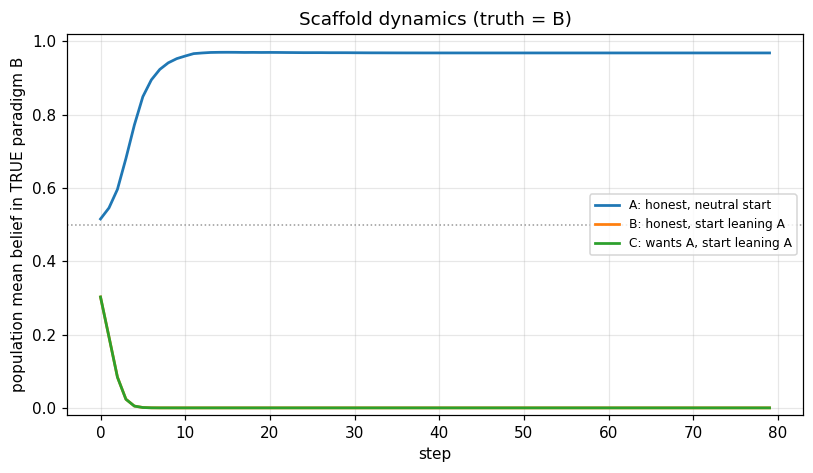

A: honest, neutral start        : q(B)=0.97 occ(B)=0.97 capture_to_truth=True against_evidence=False
B: honest, start leaning A      : q(B)=0.00 occ(B)=0.00 capture_to_truth=False against_evidence=True
C: wants A, start leaning A     : q(B)=0.00 occ(B)=0.00 capture_to_truth=False against_evidence=True


In [3]:
D_neutral = np.tile([0.5, 0.5], (N, 1))
D_lean_A  = np.tile([0.62, 0.38], (N, 1))   # start leaning the WRONG paradigm A
U_wants_A = np.tile([1.0, 0.0], (N, 1))

runs = {
    "A: honest, neutral start":      S.run(cfg, N, 80, D_per_agent=D_neutral, bu_mode="plan_tilt", seed=1),
    "B: honest, start leaning A":    S.run(cfg, N, 80, D_per_agent=D_lean_A,  bu_mode="plan_tilt", seed=1),
    "C: wants A, start leaning A":   S.run(cfg, N, 80, U_per_agent=U_wants_A, D_per_agent=D_lean_A, bu_mode="plan_tilt", seed=1),
}

fig, ax = plt.subplots(figsize=(7.5, 4.4))
for lab, out in runs.items():
    ax.plot(out["mean_qB"], lw=1.8, label=lab)
ax.axhline(0.5, color="0.6", ls=":", lw=1)
ax.set_xlabel("step"); ax.set_ylabel("population mean belief in TRUE paradigm B")
ax.set_ylim(-0.02, 1.02); ax.set_title("Scaffold dynamics (truth = B)")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

for lab, out in runs.items():
    s = O.trajectory_summary(out, cfg)
    print(f"{lab:32s}: q(B)={s['mean_belief_true']:.2f} occ(B)={s['occupancy_true']:.2f} "
          f"capture_to_truth={s['capture_to_truth']} against_evidence={s['capture_against_evidence']}")

## 3. The martingale wall: belief-utility cannot flip the basin from neutral

The decisive test. Truth = B, **neutral start**. Sweep belief-utility toward the *wrong* paradigm A.
If belief-utility were the symmetry-breaking field the plan hoped for, strong $U$ toward A would
capture A. It does not — every setting converges to truth.

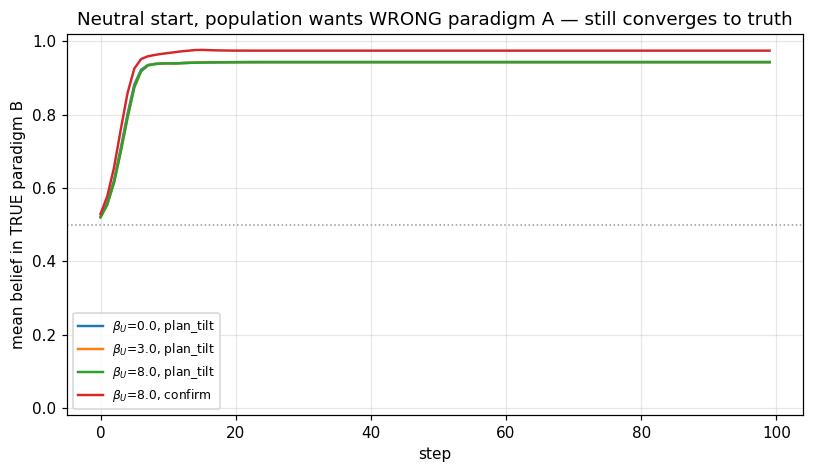

All curves rise to q(B)~0.94: belief-utility-in-policy modulates exploration,
but cannot flip the basin against honest evidence (the martingale wall).


In [4]:
fig, ax = plt.subplots(figsize=(7.5, 4.4))
for beta_U, mode in [(0.0, "plan_tilt"), (3.0, "plan_tilt"), (8.0, "plan_tilt"), (8.0, "confirm")]:
    c2 = PomdpConfig(x_grid=cfg.x_grid, true_paradigm=1, q_reliability=0.85,
                     gamma_policy=2.0, beta_U=beta_U)
    U = np.tile([1.0, 0.0], (N, 1))   # wants the WRONG paradigm A
    out = S.run(c2, N, 100, U_per_agent=U, D_per_agent=D_neutral, bu_mode=mode, seed=7)
    ax.plot(out["mean_qB"], lw=1.6, label=fr"$\beta_U$={beta_U}, {mode}")
ax.axhline(0.5, color="0.6", ls=":", lw=1)
ax.set_xlabel("step"); ax.set_ylabel("mean belief in TRUE paradigm B")
ax.set_ylim(-0.02, 1.02)
ax.set_title("Neutral start, population wants WRONG paradigm A — still converges to truth")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print("All curves rise to q(B)~0.94: belief-utility-in-policy modulates exploration,\n"
      "but cannot flip the basin against honest evidence (the martingale wall).")

## Verdict — scaffold works; capture mechanism needs a decision

**Working (Phase-1 green):** the fixed-state epistemic POMDP runs end-to-end; state inference, the
custom belief-utility EFE term, the inter-agent social channel, and the four order parameters are all
wired and validated. Regression holds (`beta_U=0` = pure EFE); the social fold + initial conditions
produce paradigm lock-in (cell 2 run B).

**Structural finding (surfaced, not forced):** belief-utility confined to policy **cannot** drive
capture-against-evidence (cell 3) — the martingale wall. So the plan's "belief-utility is the
symmetry-breaking field" needs revisiting. Three faithful options for where capture lives:

1. **Theory-ladenness via per-agent $A_\theta$ (option B's own content, not yet wired):** belief-utility
   makes an agent *commit* to a paradigm → it interprets data through that paradigm's likelihood →
   honest Bayes through a biased likelihood yields capture. Most faithful; needs per-agent $A_\theta$.
2. **NB16-style belief field:** $h_U$ added to the belief (touches the update) — validated in NB16 but
   the thing the design forbade (NB14 blow-up risk; needs a *bounded* form).
3. **Social fold + asymmetric initial conditions / trust:** keep belief-utility as exploration-only;
   capture is sociological (who you start near, who you trust), not motivational.

This is the decision to take to David (it bears on the exogenous-vs-agent-modelled-dynamics question).
The scaffold supports all three with localized changes.